In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io

In [3]:
def leer_csv(ruta_archivo):
    """
    Función para leer un archivo CSV con cabecera. Los datos están separados por comas y están todos (valores y texto) entre comillas " "

    """
    try:
        df = pd.read_csv(
            ruta_archivo,
            sep=',',          # Indicamos que el separador es la coma
            header=0,         # Indicamos que la fila 0 (la primera) tiene las etiquetas
            quotechar='"'     # Le decimos que ignore las comas que estén dentro de las comillas
        )
        print("¡Archivo CSV cargado con éxito!")
        return df
        
    except FileNotFoundError:
        print(f"Error: No se ha encontrado el archivo en la ruta '{ruta_archivo}'.")
        return None
    except Exception as e:
        print(f"Ocurrió un error inesperado al leer el CSV: {e}")
        return None



In [4]:
colores = {
   0: '#C72A66',     # Frambuesa oscuro (test-model_082337)
   1: '#B16A3C',      # Bronce / Marrón cobrizo (test-model_080952)
   2: '#1E8675',   # Verde azulado / Teal (test-model_060949)
   3: "#7D1485"  # Fucsia vibrante (test-model_051324)
}

In [5]:
accuracy_val=leer_csv('accuracy_valclass_total.csv')
accuracy_val_day=leer_csv('accuracy_valclass_day.csv')
accuracy_val_night=leer_csv('accuracy_valclass_night.csv')

etiquetas = accuracy_val.columns.tolist()
print("Las etiquetas del archivo accuracy_valheight.csv son:")
for etiqueta in etiquetas:
    print(f" -> '{etiqueta}'")

etiquetas_day = accuracy_val_day.columns.tolist()
print("Las etiquetas del archivo accuracy_valheight_day.csv son:")
for etiqueta in etiquetas_day:
    print(f" -> '{etiqueta}'")

etiquetas_night = accuracy_val_night.columns.tolist()
print("Las etiquetas del archivo accuracy_valheight_night.csv son:")
for etiqueta in etiquetas_night:
    print(f" -> '{etiqueta}'")

epocas=accuracy_val['Step']
epocas=round(epocas/(epocas.iloc[-1]/100))

epocas_day=accuracy_val_day['Step']
epocas_day=round(epocas_day/(epocas_day.iloc[-1]/100))

epocas_night=accuracy_val_night['Step']
epocas_night=round(epocas_night/(epocas_night.iloc[-1]/73)) #early stopping en la época 73



¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!
Las etiquetas del archivo accuracy_valheight.csv son:
 -> 'Step'
 -> 'test-model_251519 - Val Accuracy Validación'
 -> 'test-model_251519 - Val Accuracy Validación__MIN'
 -> 'test-model_251519 - Val Accuracy Validación__MAX'
Las etiquetas del archivo accuracy_valheight_day.csv son:
 -> 'Step'
 -> 'test-model_132024 - Val Accuracy Validación'
 -> 'test-model_132024 - Val Accuracy Validación__MIN'
 -> 'test-model_132024 - Val Accuracy Validación__MAX'
Las etiquetas del archivo accuracy_valheight_night.csv son:
 -> 'Step'
 -> 'test-model_240039 - Val Accuracy Validación'
 -> 'test-model_240039 - Val Accuracy Validación__MIN'
 -> 'test-model_240039 - Val Accuracy Validación__MAX'


<function matplotlib.pyplot.show(close=None, block=None)>

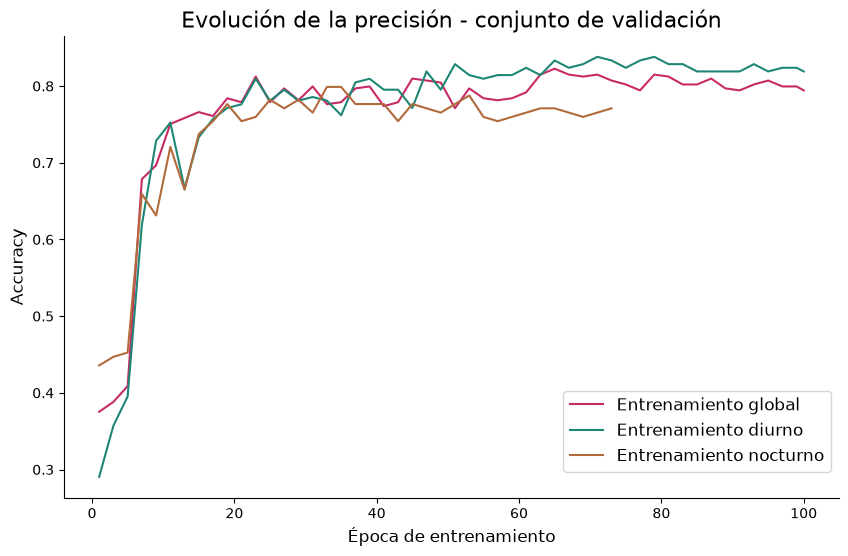

In [6]:
plt.figure(figsize=(10,6))

plt.plot(epocas, accuracy_val[etiquetas[1]], linewidth=1.5, color=colores[0], label='Entrenamiento global')
plt.plot(epocas_day, accuracy_val_day[etiquetas_day[1]], linewidth=1.5, color=colores[2], label='Entrenamiento diurno')
plt.plot(epocas_night, accuracy_val_night[etiquetas_night[1]], linewidth=1.5, color=colores[1], label='Entrenamiento nocturno')

plt.xlabel('Época de entrenamiento', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Evolución de la precisión - conjunto de validación', fontsize=16)
plt.legend(fontsize=12,  bbox_to_anchor=(1.0, 0.25))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show

In [7]:
loss_train=leer_csv('loss_class_total.csv')
loss_train_day=leer_csv('loss_class_day.csv')
loss_train_night=leer_csv('loss_class_night.csv')

etiquetas2 = loss_train.columns.tolist()

etiquetas2_day = loss_train_day.columns.tolist()

etiquetas2_night = loss_train_night.columns.tolist()

epocas2=loss_train['Step']
epocas2=epocas2/(epocas2.iloc[-1]/100)

epocas2_day=loss_train_day['Step']
epocas2_day=epocas2_day/(epocas2_day.iloc[-1]/100)

epocas2_night=loss_train_night['Step']
epocas2_night=epocas2_night/(epocas2_night.iloc[-1]/73)



¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!
¡Archivo CSV cargado con éxito!


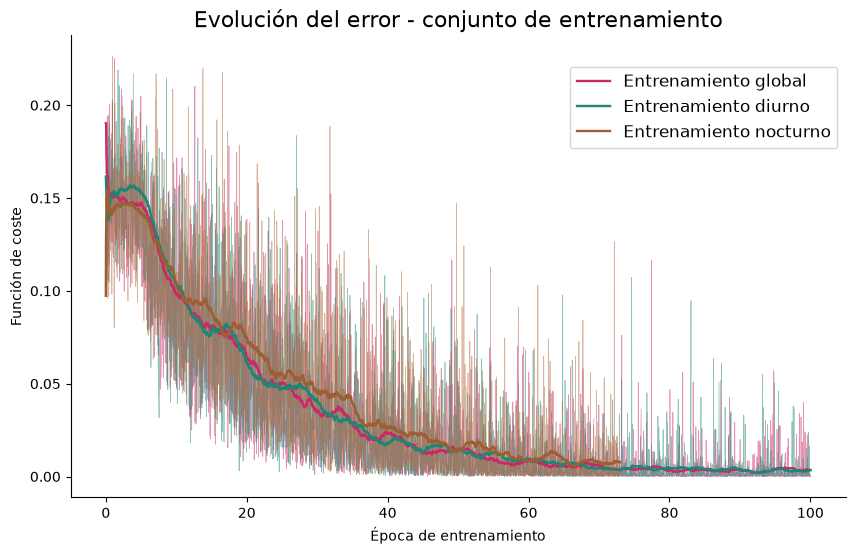

In [8]:
plt.figure(figsize=(10,6))

everyN=3
window=100

# 1. Extraemos los datos crudos de todos los modelos
train = loss_train[etiquetas2[1]][::everyN]
train_day = loss_train_day[etiquetas2_day[1]][::everyN]
train_night = loss_train_night[etiquetas2_night[1]][::everyN]

train_avg = train.rolling(window=window, min_periods=1).mean()
train_day_avg=train_day.rolling(window=window, min_periods=1).mean()
train_night_avg=train_night.rolling(window=window, min_periods=1).mean()



plt.plot(epocas2[::everyN], train, color=colores[0], linewidth=0.5, alpha=0.5)
plt.plot(epocas2_day[::everyN], train_day, color=colores[2], linewidth=0.5, alpha=0.5)
plt.plot(epocas2_night[::everyN], train_night, color=colores[1], linewidth=0.5, alpha=0.5)

plt.plot(epocas2[::everyN], train_avg, label='Entrenamiento global', color=colores[0], linewidth=1.7)
plt.plot(epocas2_day[::everyN], train_day_avg, label='Entrenamiento diurno', color=colores[2], linewidth=1.7)
plt.plot(epocas2_night[::everyN], train_night_avg, label='Entrenamiento nocturno', color="#9D5E34", linewidth=1.7)

plt.xlabel('Época de entrenamiento')
plt.ylabel('Función de coste')
plt.title('Evolución del error - conjunto de entrenamiento', fontsize=16)
plt.legend(fontsize=12, bbox_to_anchor=(1.0, 0.95))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Text(0.5, 1.0, 'Matriz de Confusión - Modelo global')

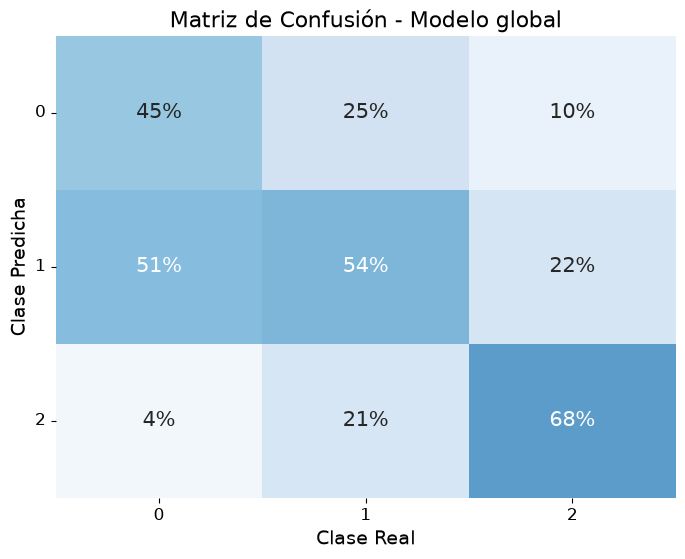

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

df = pd.read_csv(r"C:\Users\USUARIO\Documents\TFG_CLASIF\results\test-model_251519\predicciones_detalladas.txt", sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

real = df['Real (m)']
predicho = df['Predicho (m)']

cm = confusion_matrix(real, predicho).T
n_classes = cm.shape[0]
cm_sums = cm.sum(axis=0, keepdims=True)
cm_percent = np.divide(cm.astype(np.float32), cm_sums, out=np.zeros_like(cm, dtype=float), where=cm_sums!=0) * 100

annot_labels = np.array([[f"{val:.0f}%" for val in row] for row in cm_percent])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=annot_labels, cbar=False, fmt="",
        cmap=sns.color_palette("Blues", 12, as_cmap=True), alpha=0.8, annot_kws={"size": 15}, vmin=0, vmax=100,
        xticklabels=[f"{j}" for j in range(n_classes)],
        yticklabels=[f"{i}" for i in range(n_classes)],
        cbar_kws={'format': '%.2f%%'})
plt.xticks(fontsize=12)             
plt.yticks(fontsize=12, rotation=0)

plt.ylabel("Clase Predicha", fontsize=14)
plt.xlabel("Clase Real", fontsize=14)
plt.title("Matriz de Confusión - Modelo global", fontsize=16)



Text(0.5, 1.0, 'Matriz de Confusión - Modelo Diurno')

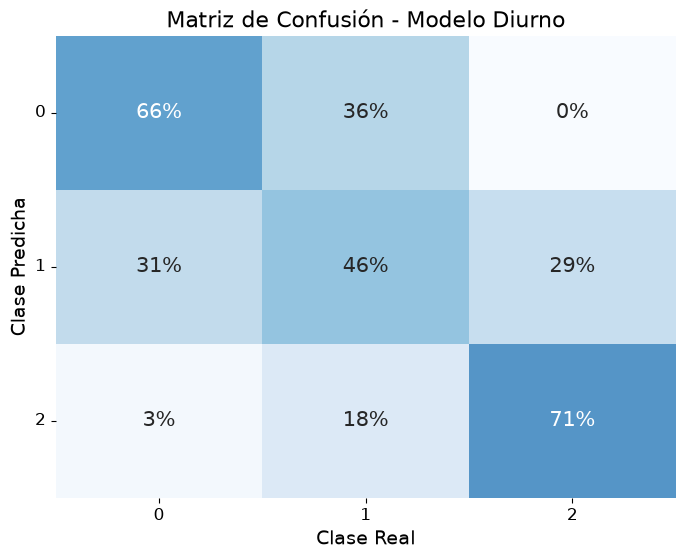

In [10]:
df = pd.read_csv(r"C:\Users\USUARIO\Documents\TFG_CLASIF\results\test-model_132024\predicciones_detalladas.txt", sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

real = df['Real (m)']
predicho = df['Predicho (m)']

cm = confusion_matrix(real, predicho).T
n_classes = cm.shape[0]
cm_sums = cm.sum(axis=0, keepdims=True)
cm_percent = np.divide(cm.astype(np.float32), cm_sums, out=np.zeros_like(cm, dtype=float), where=cm_sums!=0) * 100

annot_labels = np.array([[f"{val:.0f}%" for val in row] for row in cm_percent])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=annot_labels, cbar=False, fmt="",
        cmap=sns.color_palette("Blues", 12, as_cmap=True), alpha=0.8, annot_kws={"size": 15}, vmin=0, vmax=100,
        xticklabels=[f"{j}" for j in range(n_classes)],
        yticklabels=[f"{i}" for i in range(n_classes)],
        cbar_kws={'format': '%.0f%%'})
plt.xticks(fontsize=12)             
plt.yticks(fontsize=12, rotation=0)

plt.ylabel("Clase Predicha", fontsize=14)
plt.xlabel("Clase Real", fontsize=14)
plt.title("Matriz de Confusión - Modelo Diurno", fontsize=16)

Text(0.5, 1.0, 'Matriz de Confusión - Modelo nocturno')

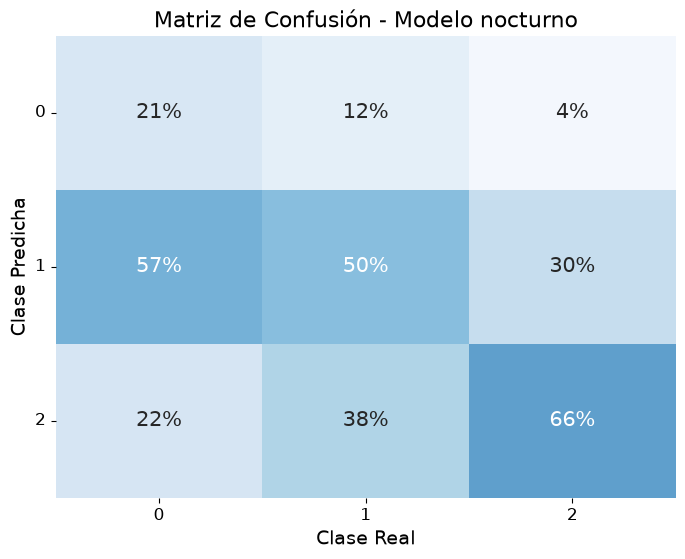

In [13]:
df = pd.read_csv(r"C:\Users\USUARIO\Documents\TFG_CLASIF\results\test-model_240039\predicciones_detalladas.txt", sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

real = df['Real (m)']
predicho = df['Predicho (m)']

cm = confusion_matrix(real, predicho).T
n_classes = cm.shape[0]
cm_sums = cm.sum(axis=0, keepdims=True)
cm_percent = np.divide(cm.astype(np.float32), cm_sums, out=np.zeros_like(cm, dtype=float), where=cm_sums!=0) * 100

cm_percent_rounded = np.round(cm_percent)


for j in range(n_classes):
    col_sum = np.sum(cm_percent_rounded[:, j])
    if col_sum != 100.0 and cm_sums[0, j] != 0:
        diff = 100.0 - col_sum
        max_idx = np.argmax(cm_percent[:, j])
        cm_percent_rounded[max_idx, j] += diff


annot_labels = np.array([[f"{val:.0f}%" for val in row] for row in cm_percent_rounded])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=annot_labels, cbar=False, fmt="",
        cmap=sns.color_palette("Blues", 12, as_cmap=True), alpha=0.8, annot_kws={"size": 15}, vmin=0, vmax=100,
        xticklabels=[f"{j}" for j in range(n_classes)],
        yticklabels=[f"{i}" for i in range(n_classes)],
        cbar_kws={'format': '%.2f%%'})
plt.xticks(fontsize=12)             
plt.yticks(fontsize=12, rotation=0)

plt.ylabel("Clase Predicha", fontsize=14)
plt.xlabel("Clase Real", fontsize=14)
plt.title("Matriz de Confusión - Modelo nocturno", fontsize=16)